<a href="https://colab.research.google.com/github/kefasmanu/ScaDS-2026-/blob/main/activation_patching.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mechanistic Interpretability:  Activation Patching
---
We explore activation interventions on two different tasks:
1. **Indirect Object Identification (IOI)** — tracking how text structures guide name lookup loops.
2. **Factual Knowledge Recall** — locating the exact key-value database coordinates where real-world facts reside.

#### Mathematical Framework
Rather than inspecting single sentences, we process balanced distributions of **8 synchronized prompts** per domain. We monitor the absolute shift in the **Logit Difference** between the clean target and the corrupted target:
$$\text{Value} = \text{Metric}(\text{Patched}) - \text{Metric}(\text{Corrupted Baseline})$$

* A value of **0 (Pure White)** indicates no causal impact: Patching the clean signal back into this node has zero effect on the model's output. This indicates the node is not a component of the active circuit for this specific task.that patching the clean activation back into the model has zero effect.
* A **Positive Value (Dark Blue)** indicates causal restoration: When the model is running on corrupted input, restoring the clean signal to this specific component single-handedly recovers the clean task performance.
* A **Negative Value (Dark Red)** reveals causal interference: This reveals an active adversary or an alternate path. Forcing a clean signal here makes the corrupted model perform even worse, showing that this node normally acts to suppress alternative or incorrect responses during the task.

For the experiments, we are going to use [TransformerLens](https://github.com/TransformerLensOrg/TransformerLens).

In [ ]:
!pip install transformer_lens
# Cell 1: Environment Setup & Core Dependencies
import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

import transformer_lens
import transformer_lens.utils as utils
from transformer_lens import HookedTransformer
import transformer_lens.patching as patching

# Optimize VRAM space by disabling tracking gradients
torch.set_grad_enabled(False)
print("✅ Interpretability framework loaded successfully. VRAM pathways optimized.")

### Step 1: Initializing the Foundational Model
We load a standard pre-trained `gpt2-small` transformer architecture consisting of **12 layers** and **12 attention heads per layer** (144 attention heads total).

To enable detailed tracking inside the multi-head layers later, we configure `model.cfg.use_attn_result = True` to preserve the individual output tensors generated by each attention head before they merge back into the main residual stream.

In [ ]:
# Cell 2: Load Foundational Transformer Model
device = "cuda" if torch.cuda.is_available() else "cpu"
model = HookedTransformer.from_pretrained("gpt2-small", device=device)
model.cfg.use_attn_result = True
print(f"✅ Model completely cached on hardware target: {device}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Loaded pretrained model gpt2-small into HookedTransformer
✅ Model completely cached on hardware target: cuda


### Step 2: Preparing the Batched Cognitive Task Datasets
To isolate true generalized circuits, we must avoid tokenization padding bugs or positional shifting. Each sentence in our 8-prompt arrays is carefully formatted to contain the **exact same token sequence length count** under the GPT-2 tokenizer.

In [ ]:
# Cell 3: Comprehensive Batched Multi-Task Profiles Dataset
task_profiles = {
    "Indirect Object Identification (IOI)": {
        "clean_prompts": [
            "When John and Mary went to the shops, John gave the bag to",
            "When John and Mary went to the shops, Mary gave the bag to",
            "When Tom and James went to the park, James gave the ball to",
            "When Tom and James went to the park, Tom gave the ball to",
            "When Dan and Sid went to the shops, Sid gave an apple to",
            "When Dan and Sid went to the shops, Dan gave an apple to",
            "After Martin and Amy went to the park, Amy gave a drink to",
            "After Martin and Amy went to the park, Martin gave a drink to"
        ],
        "answers": [
            (" Mary", " John"), (" John", " Mary"),
            (" Tom", " James"), (" James", " Tom"),
            (" Dan", " Sid"), (" Sid", " Dan"),
            (" Martin", " Amy"), (" Amy", " Martin")
        ]
    },
    "Factual Recall (ROME Style)": {
        "clean_prompts": [
            "The beautiful historic city of Paris is known as the capital of",
            "The beautiful historic city of Rome is known as the capital of",
            "The beautiful historic city of Berlin is known as the capital of",
            "The beautiful historic city of Tokyo is known as the capital of",
            "The beautiful historic city of London is known as the capital of",
            "The beautiful historic city of Madrid is known as the capital of",
            "The beautiful historic city of Cairo is known as the capital of",
            "The beautiful historic city of Beijing is known as the capital of"
        ],
        "answers": [
            (" France", " Italy"), (" Italy", " France"),
            (" Germany", " Japan"), (" Japan", " Germany"),
            (" UK", " Spain"), (" Spain", " UK"),
            (" Egypt", " China"), (" China", " Egypt")
        ]
    }
}
print(f"✅ Successfully balanced and loaded {len(task_profiles)} multi-prompt task profiles.")

✅ Successfully balanced and loaded 2 multi-prompt task profiles.


### Step 3: Layer-Level Spatial Activation Patching
Our first diagnostic intervention targets the **main residual stream** (`resid_pre`) across every layer and token position. Think of the residual stream as the information highway of the transformer.

By overriding the corrupted highway activations with clean activations at specific coordinates, we can map exactly when and where the target features are constructed.


GENERATING SPATIAL CIRCUIT TOPOGRAPHY: Indirect Object Identification (IOI)


  0%|          | 0/180 [00:00<?, ?it/s]

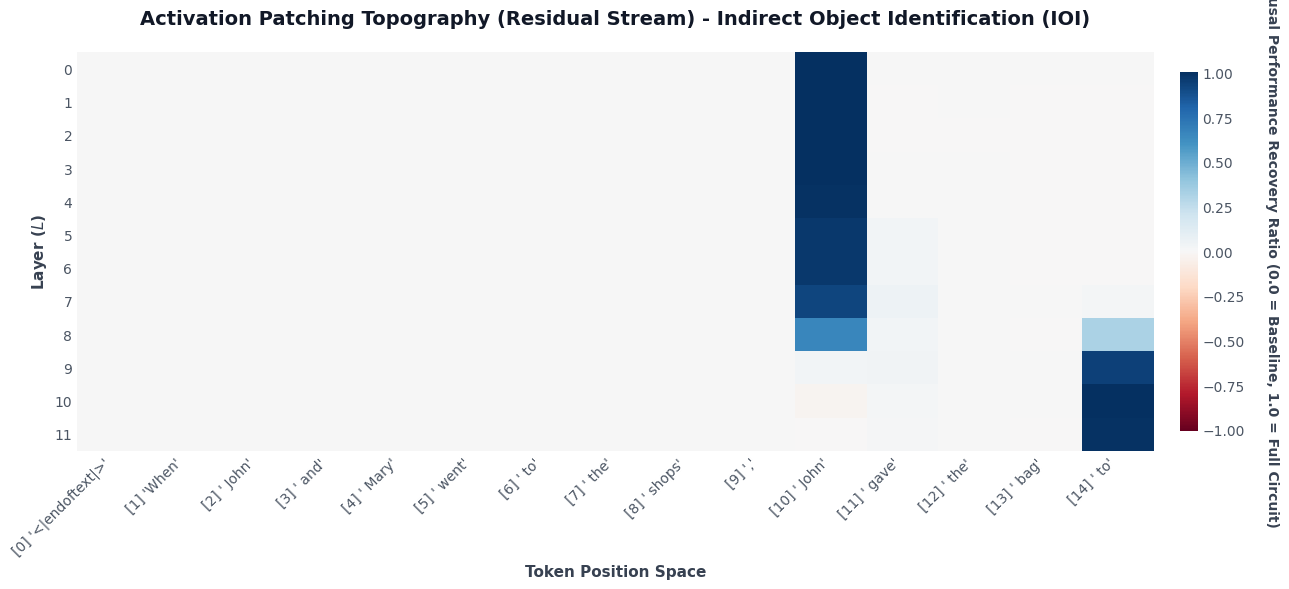


GENERATING SPATIAL CIRCUIT TOPOGRAPHY: Factual Recall (ROME Style)


  0%|          | 0/156 [00:00<?, ?it/s]

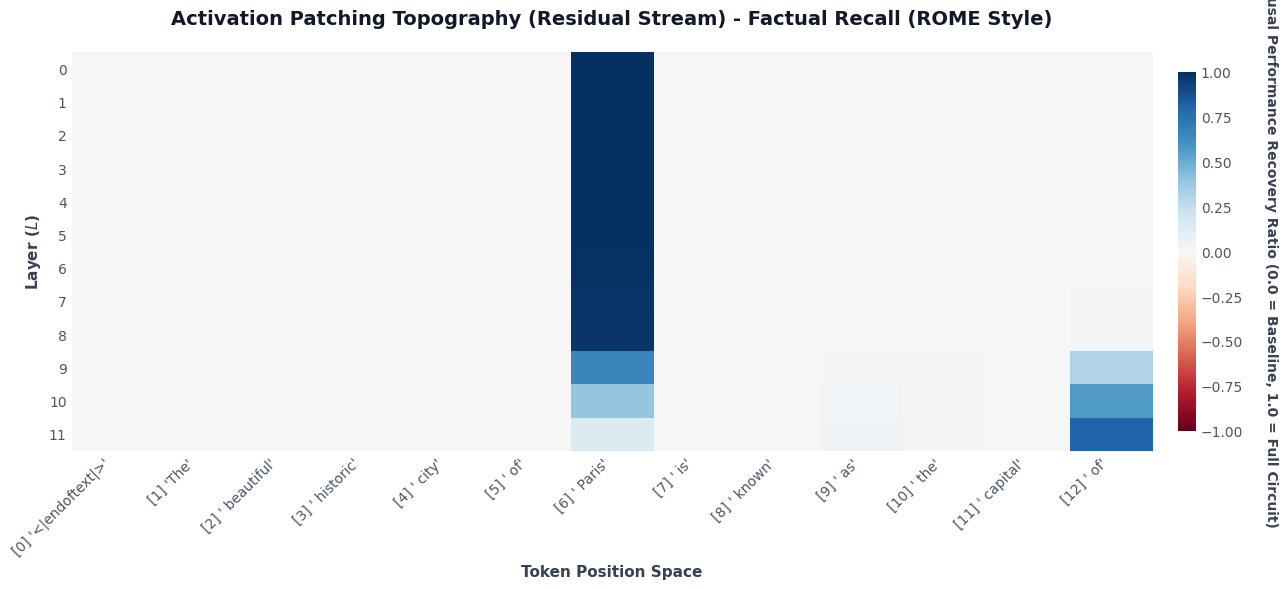

In [ ]:
# Cell 4: Spatial Layer-Level Residual Stream Patching Topography
for task_name, profile in task_profiles.items():
    print("\n" + "="*70)
    print(f"GENERATING SPATIAL CIRCUIT TOPOGRAPHY: {task_name}")
    print("="*70)

    # 1. Setup tokens securely on the active device
    clean_tokens = model.to_tokens(profile["clean_prompts"]).to(device)

    # Secure token permutation trick
    corrupted_tokens = clean_tokens[[(i+1 if i%2==0 else i-1) for i in range(len(clean_tokens))]]

    # 2. Extract baseline logits & clean cache efficiently
    model.reset_hooks()
    clean_logits, clean_cache = model.run_with_cache(clean_tokens, return_type="logits")
    corrupted_logits = model(corrupted_tokens) # Don't cache the corrupted pass! Saves major VRAM

    # 3. Vectorize answer token collection
    answer_token_indices = torch.tensor([
        [model.to_single_token(ans[0]), model.to_single_token(ans[1])] for ans in profile["answers"]
    ], device=device)

    # 4. Standardized Logit Metric Function
    def batched_logit_diff(logits, indices=answer_token_indices):
        target_logits = logits[:, -1, :]
        correct_logits = target_logits.gather(1, indices[:, 0].unsqueeze(1))
        incorrect_logits = target_logits.gather(1, indices[:, 1].unsqueeze(1))
        return (correct_logits - incorrect_logits).mean()

    # Calculate baseline boundaries
    clean_score = batched_logit_diff(clean_logits).item()
    corrupted_score = batched_logit_diff(corrupted_logits).item()

    # 5. Formal Normalized Metric Wrapper for the Patching Sweep
    def normalized_patching_metric(patched_logits):
        patched_score = batched_logit_diff(patched_logits)
        # Scale: 0 = completely corrupted baseline, 1 = 100% restored clean circuit
        return (patched_score - corrupted_score) / (clean_score - corrupted_score)

    # 6. Execute highly-optimized structural patching sweep
    # This automatically reads the clean_cache and injects it into the corrupted runs
    raw_layer_results = patching.get_act_patch_resid_pre(
        model, corrupted_tokens, clean_cache, normalized_patching_metric
    )

    # Process tensor for visualization cleanly using TransformerLens abstractions
    matrix_data = raw_layer_results.detach().cpu().squeeze().numpy()
    if matrix_data.ndim > 2:
        matrix_data = matrix_data[0]

    # 7. Clean up axis labels natively
    raw_str_tokens = model.to_str_tokens(clean_tokens[0])
    axis_labels = [f"[{i}] {tok!r}" for i, tok in enumerate(raw_str_tokens)]

    # 8. matplotlib design
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.set_facecolor('#F9FAFB')
    fig.patch.set_facecolor('white')

    # Symmetric scale centered on zero
    max_range = max(abs(matrix_data.min()), abs(matrix_data.max()), 1.0)

    heatmap = ax.imshow(
        matrix_data,
        cmap="RdBu",
        aspect="auto",
        vmin=-max_range,
        vmax=max_range
    )

    # Styling labels and titles cleanly
    ax.set_title(f"Activation Patching Topography (Residual Stream) - {task_name}", fontsize=14, fontweight="bold", pad=20, color="#111827")
    ax.set_ylabel("Layer ($L$)", fontsize=11, color="#374151", fontweight="semibold")
    ax.set_xlabel("Token Position Space", fontsize=11, color="#374151", fontweight="semibold")

    ax.set_yticks(np.arange(matrix_data.shape[0]))
    ax.set_xticks(np.arange(matrix_data.shape[1]))
    ax.set_xticklabels(axis_labels, rotation=45, ha="right", fontsize=10, color="#4B5563")
    ax.tick_params(colors="#4B5563", labelsize=10, length=0)

    # Clean borders
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Informative Colorbar
    cbar = fig.colorbar(heatmap, ax=ax, pad=0.02, shrink=0.9)
    cbar.outline.set_visible(False)
    cbar.ax.tick_params(labelsize=10, colors="#4B5563", length=0)
    cbar.set_label("Causal Performance Recovery Ratio (0.0 = Baseline, 1.0 = Full Circuit)", rotation=270, labelpad=25, color="#374151", fontweight="bold")

    plt.tight_layout()
    plt.show()

### Step 4: Component-Level Attention Head Dissection
Now that we know which layers are causally active, we zoom in to look at the individual attention heads inside those layers. A model layer is not a single computation block—it contains 12 separate attention heads working in parallel.

The code below evaluates all attention heads simultaneously. It automatically calculates a statistical threshold and draws a **black bounding box** around the top 5% most powerful heads.


MAPPING ATTENTION COMPONENT CIRCUITS: Indirect Object Identification (IOI)


  0%|          | 0/144 [00:00<?, ?it/s]

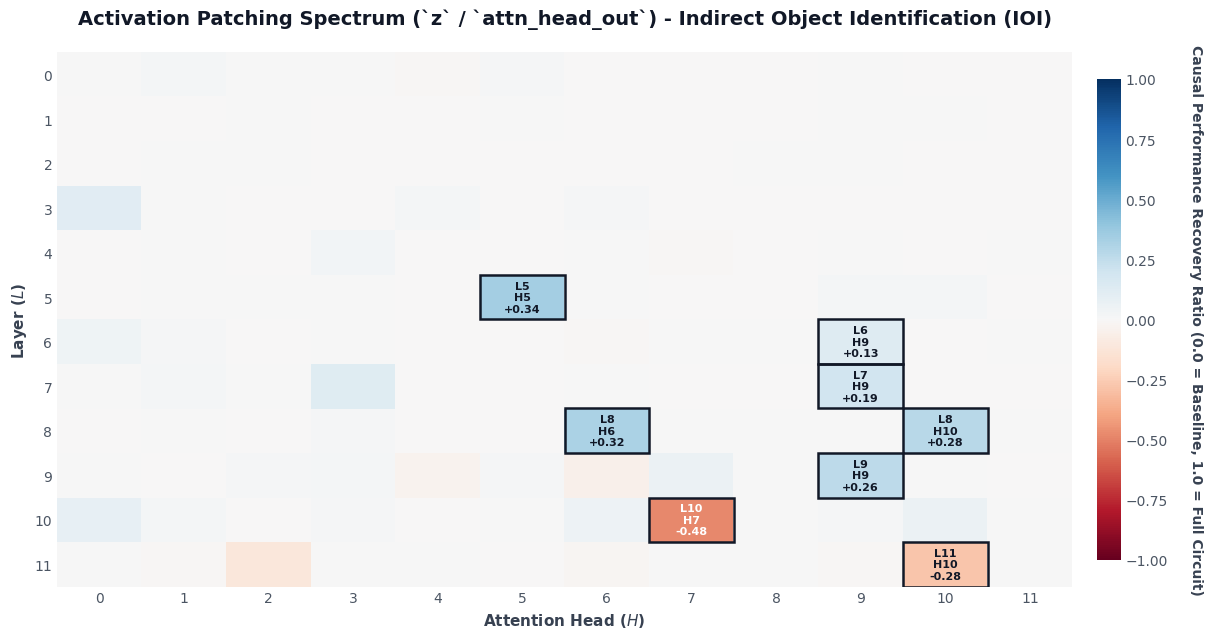


MAPPING ATTENTION COMPONENT CIRCUITS: Factual Recall (ROME Style)


  0%|          | 0/144 [00:00<?, ?it/s]

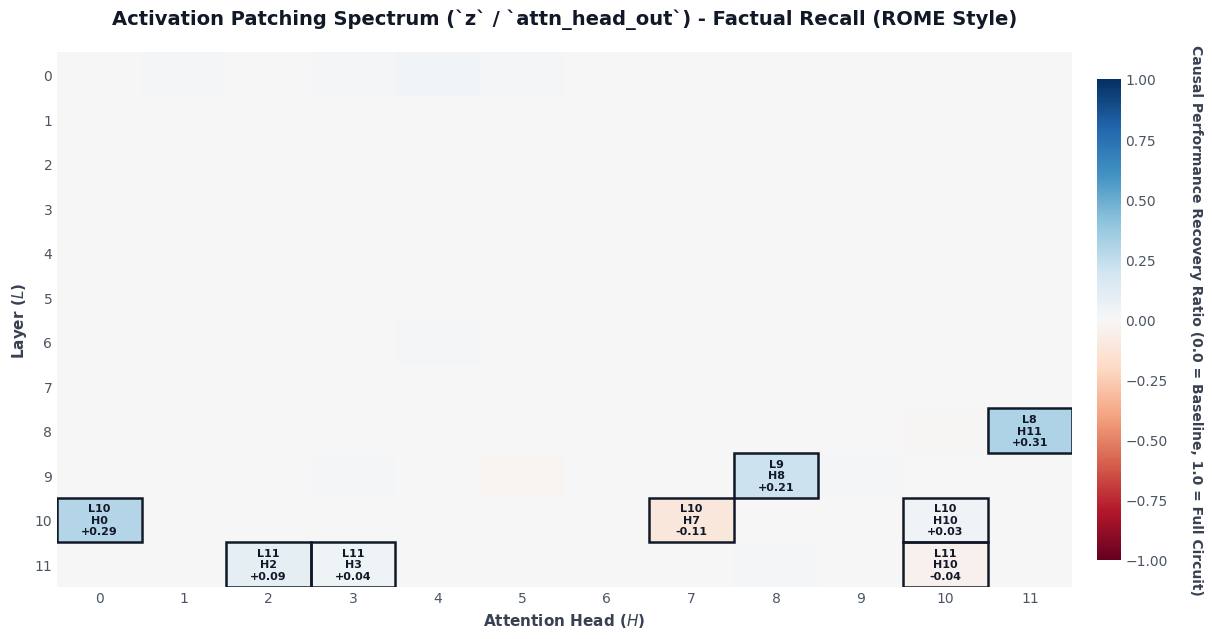

In [ ]:
# Cell 5: Publication-Grade Attention Head Patching Spectrum (Annotated Grid)
for task_name, profile in task_profiles.items():
    print("\n" + "="*70)
    print(f"MAPPING ATTENTION COMPONENT CIRCUITS: {task_name}")
    print("="*70)

    # 1. Setup tokens securely on the active device
    clean_tokens = model.to_tokens(profile["clean_prompts"]).to(device)

    # Secure token permutation trick
    corrupted_tokens = clean_tokens[[(i+1 if i%2==0 else i-1) for i in range(len(clean_tokens))]]

    # 2. Extract baseline logits & clean cache efficiently
    model.reset_hooks()
    clean_logits, clean_cache = model.run_with_cache(clean_tokens, return_type="logits")
    corrupted_logits = model(corrupted_tokens) # Avoid double-caching; saves VRAM

    # 3. Vectorize answer token collection
    answer_token_indices = torch.tensor([
        [model.to_single_token(ans[0]), model.to_single_token(ans[1])] for ans in profile["answers"]
    ], device=device)

    # 4. Standardized Logit Metric Function
    def batched_logit_diff(logits, indices=answer_token_indices):
        target_logits = logits[:, -1, :]
        correct_logits = target_logits.gather(1, indices[:, 0].unsqueeze(1))
        incorrect_logits = target_logits.gather(1, indices[:, 1].unsqueeze(1))
        return (correct_logits - incorrect_logits).mean()

    # Calculate baseline boundaries
    clean_score = batched_logit_diff(clean_logits).item()
    corrupted_score = batched_logit_diff(corrupted_logits).item()

    # 5. Normalized Metric Wrapper for Causal Scaling (0.0 to 1.0)
    def normalized_patching_metric(patched_logits):
        patched_score = batched_logit_diff(patched_logits)
        return (patched_score - corrupted_score) / (clean_score - corrupted_score)

    # 6. Execute highly-optimized attention head output patching sweep
    raw_head_results = patching.get_act_patch_attn_head_out_all_pos(
        model, corrupted_tokens, clean_cache, normalized_patching_metric
    )

    # Process tensor cleanly into a standard [layer, head] numpy grid
    head_matrix = raw_head_results.detach().cpu().numpy()

    # 7. matplotlib layout design
    fig, ax = plt.subplots(figsize=(13, 6.5))
    ax.set_facecolor('#F9FAFB')
    fig.patch.set_facecolor('white')

    # Symmetric scale centered perfectly at 0.0
    max_range = max(abs(head_matrix.min()), abs(head_matrix.max()), 1.0)

    heatmap = ax.imshow(
        head_matrix,
        cmap="RdBu",
        aspect="auto",
        vmin=-max_range,
        vmax=max_range
    )

    # Styling labels and titles cleanly
    ax.set_title(f"Activation Patching Spectrum (`z` / `attn_head_out`) - {task_name}", fontsize=14, fontweight="bold", pad=20, color="#111827")
    ax.set_ylabel("Layer ($L$)", fontsize=11, color="#374151", fontweight="semibold")
    ax.set_xlabel("Attention Head ($H$)", fontsize=11, color="#374151", fontweight="semibold")

    ax.set_yticks(np.arange(model.cfg.n_layers))
    ax.set_xticks(np.arange(model.cfg.n_heads))
    ax.tick_params(colors="#4B5563", labelsize=10, length=0)

    # Hide unnecessary grid spines
    for spine in ax.spines.values():
        spine.set_visible(False)

    # 8. Dynamic Target Highlighting (Top 5% of impactful attention circuits)
    threshold = np.percentile(np.abs(head_matrix), 95)

    for layer in range(head_matrix.shape[0]):
        for head in range(head_matrix.shape[1]):
            val = head_matrix[layer, head]
            if np.abs(val) >= threshold and threshold > 0:
                # Draw sharp focus box around active circuit nodes
                ax.add_patch(plt.Rectangle((head - 0.5, layer - 0.5), 1, 1, fill=False, edgecolor='#111827', lw=1.8))

                # Dynamic contrast text coloring: white text for deep saturated cells, dark text for light tones
                text_color = "white" if np.abs(val) > (max_range * 0.45) else "#111827"
                ax.text(
                    head, layer, f"L{layer}\nH{head}\n{val:+.2f}",
                    ha="center", va="center", color=text_color,
                    fontsize=8, fontweight="bold"
                )

    # Informative Colorbar
    cbar = fig.colorbar(heatmap, ax=ax, pad=0.02, shrink=0.9)
    cbar.outline.set_visible(False)
    cbar.ax.tick_params(labelsize=10, colors="#4B5563", length=0)
    cbar.set_label("Causal Performance Recovery Ratio (0.0 = Baseline, 1.0 = Full Circuit)", rotation=270, labelpad=25, color="#374151", fontweight="bold")

    plt.tight_layout()
    plt.show()

### Step 5: Multi-Panel Block Segmentation Visualizer
Our final diagnostic combines everything into a comprehensive anatomical view. We isolate the model's sub-components side-by-side using `patching.get_act_patch_block_every`:
1. **The Residual Stream Facet:** The core highway tracking information accumulation.
2. **The Attention Output Facet:** Sparse routers mapping relational and structural context shifts.
3. **The MLP Output Facet:** The model's internal associative database lookup engine.


GENERATING MULTI-PANEL BLOCK HEATMAP: Indirect Object Identification (IOI)


  0%|          | 0/180 [00:00<?, ?it/s]

  0%|          | 0/180 [00:00<?, ?it/s]

  0%|          | 0/180 [00:00<?, ?it/s]

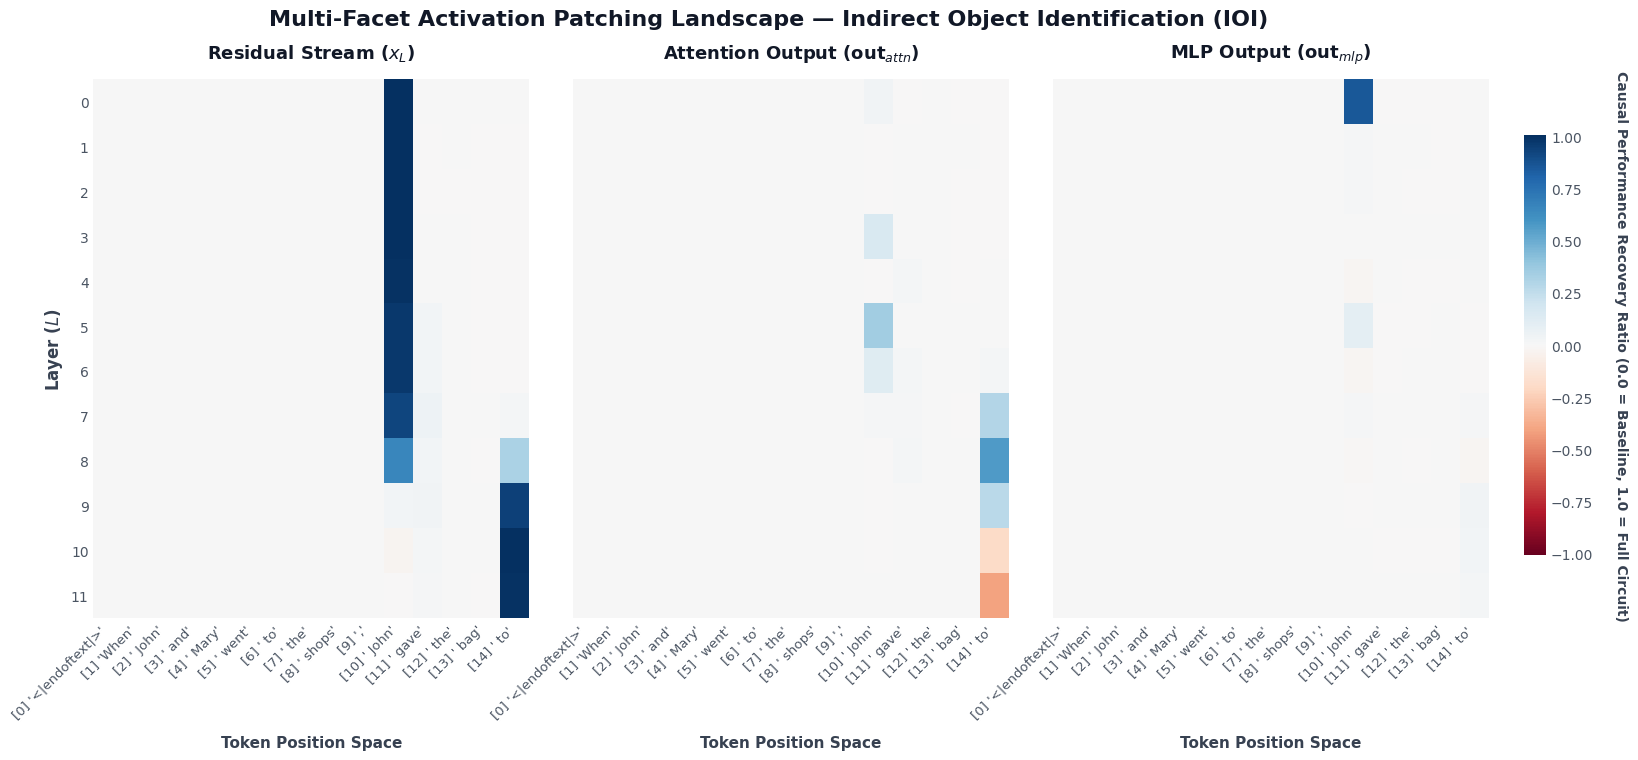


GENERATING MULTI-PANEL BLOCK HEATMAP: Factual Recall (ROME Style)


  0%|          | 0/156 [00:00<?, ?it/s]

  0%|          | 0/156 [00:00<?, ?it/s]

  0%|          | 0/156 [00:00<?, ?it/s]

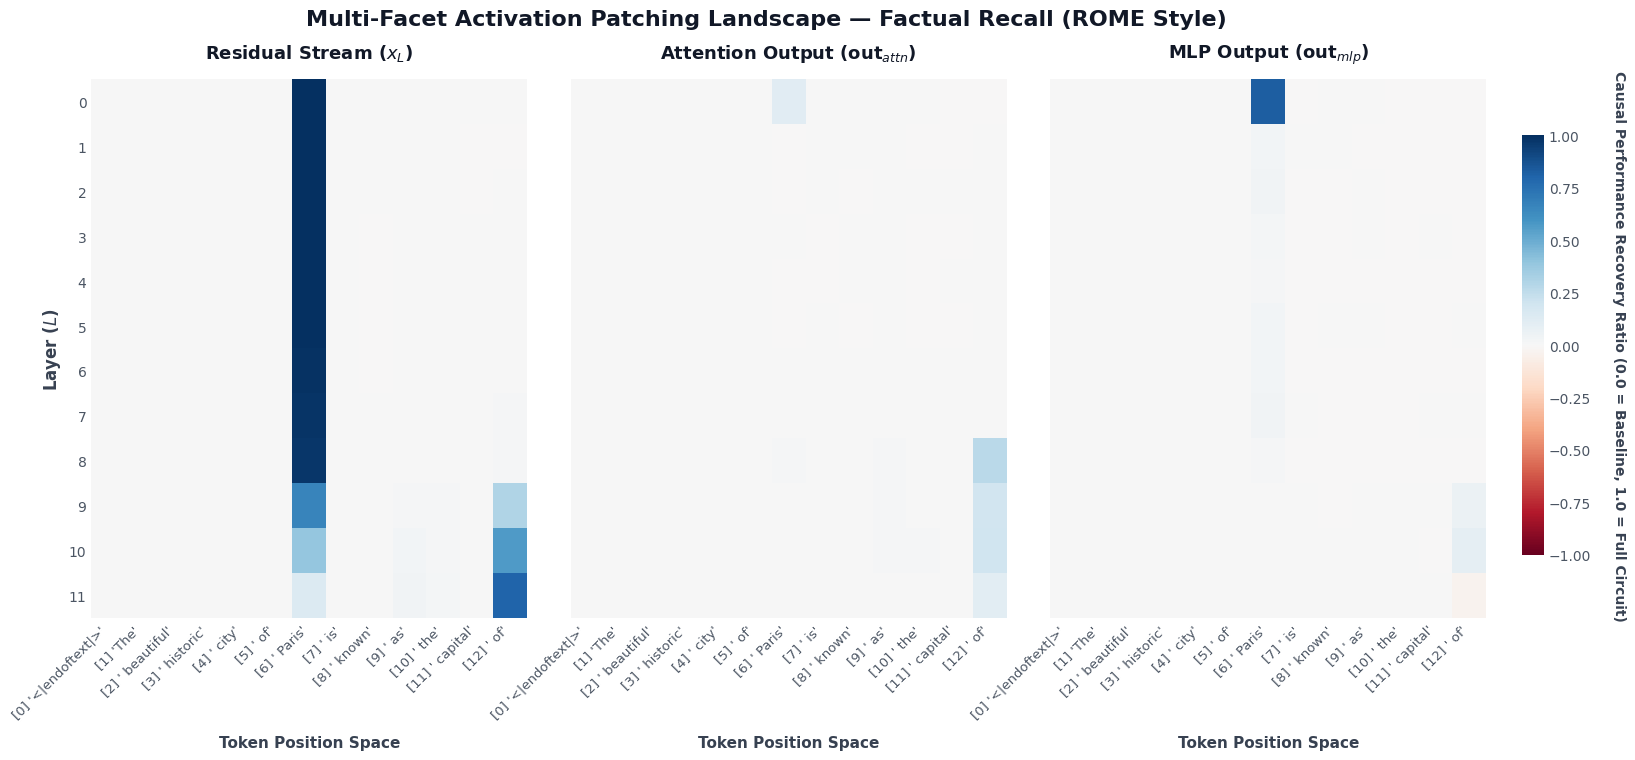

In [ ]:
# Cell 6: Complete Multi-Panel 3-Facet Block Segmentation Visualizer
for task_name, profile in task_profiles.items():
    print("\n" + "="*70)
    print(f"GENERATING MULTI-PANEL BLOCK HEATMAP: {task_name}")
    print("="*70)

    # 1. Setup tokens securely on the active device
    clean_tokens = model.to_tokens(profile["clean_prompts"]).to(device)

    # Secure token permutation trick
    corrupted_tokens = clean_tokens[[(i+1 if i%2==0 else i-1) for i in range(len(clean_tokens))]]

    # 2. Extract baseline logits & clean cache efficiently
    model.reset_hooks()
    clean_logits, clean_cache = model.run_with_cache(clean_tokens, return_type="logits")
    corrupted_logits = model(corrupted_tokens) # VRAM drop: no corrupted caching!

    # 3. Vectorize answer token collection
    answer_token_indices = torch.tensor([
        [model.to_single_token(ans[0]), model.to_single_token(ans[1])] for ans in profile["answers"]
    ], device=device)

    # 4. Standardized Logit Metric Function
    def batched_logit_diff(logits, indices=answer_token_indices):
        target_logits = logits[:, -1, :]
        correct_logits = target_logits.gather(1, indices[:, 0].unsqueeze(1))
        incorrect_logits = target_logits.gather(1, indices[:, 1].unsqueeze(1))
        return (correct_logits - incorrect_logits).mean()

    # Calculate baseline boundaries
    clean_score = batched_logit_diff(clean_logits).item()
    corrupted_score = batched_logit_diff(corrupted_logits).item()

    # 5. Normalized Metric Wrapper for Causal Scaling (0.0 to 1.0)
    def normalized_patching_metric(patched_logits):
        patched_score = batched_logit_diff(patched_logits)
        return (patched_score - corrupted_score) / (clean_score - corrupted_score)

    # 6. Execute highly-optimized all-block components patching sweep
    # Yields shape: [3, n_layers, seq_len] matching the three facets
    every_block_result = patching.get_act_patch_block_every(
        model, corrupted_tokens, clean_cache, normalized_patching_metric
    )

    block_matrix = every_block_result.detach().cpu().numpy()

    # 7. Clean up axis and facet labels natively
    raw_str_tokens = model.to_str_tokens(clean_tokens[0])
    axis_labels = [f"[{i}] {tok!r}" for i, tok in enumerate(raw_str_tokens)]
    facet_labels = ["Residual Stream ($x_L$)", r"Attention Output ($\mathbf{out}_{attn}$)", r"MLP Output ($\mathbf{out}_{mlp}$)"]

    # 8. Multi-Panel Matplotlib Layout Engine
    fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True)
    fig.patch.set_facecolor('white')

    # Symmetric color scaling centered on 0.0
    max_range = max(abs(block_matrix.min()), abs(block_matrix.max()), 1.0)

    for idx, ax in enumerate(axes):
        ax.set_facecolor('#F9FAFB')

        # Plot the specific facet matrix track [idx, layer, position]
        heatmap = ax.imshow(
            block_matrix[idx],
            cmap="RdBu",
            aspect="auto",
            vmin=-max_range,
            vmax=max_range
        )

        ax.set_title(facet_labels[idx], fontsize=13, pad=15, color="#111827", fontweight="bold")
        ax.set_xlabel("Token Position Space", fontsize=11, color="#374151", labelpad=10, fontweight="semibold")

        ax.set_xticks(np.arange(len(axis_labels)))
        ax.set_xticklabels(axis_labels, rotation=45, ha="right", fontsize=9.5, color="#4B5563")
        ax.tick_params(length=0, colors="#4B5563")

        # Hide chart junk borders
        for spine in ax.spines.values():
            spine.set_visible(False)

    # Explicit Y-axis decoration for the first facet only (due to sharey=True)
    axes[0].set_ylabel("Layer ($L$)", fontsize=12, color="#374151", fontweight="bold")
    axes[0].set_yticks(np.arange(model.cfg.n_layers))
    axes[0].set_yticklabels(np.arange(model.cfg.n_layers), fontsize=10, color="#4B5563")

    # Unified Colorbar Axis configuration
    fig.subplots_adjust(right=0.90, wspace=0.1)
    cbar_ax = fig.add_axes([0.92, 0.2, 0.012, 0.6])
    cbar = fig.colorbar(heatmap, cax=cbar_ax)
    cbar.outline.set_visible(False)
    cbar.ax.tick_params(labelsize=10, colors="#4B5563", length=0)
    cbar.set_label("Causal Performance Recovery Ratio (0.0 = Baseline, 1.0 = Full Circuit)", rotation=270, labelpad=25, color="#374151", fontweight="bold")

    fig.suptitle(f"Multi-Facet Activation Patching Landscape — {task_name}", fontsize=16, fontweight="bold", y=0.98, color="#111827")
    plt.show()